In [4]:
import sys
sys.path.append('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/')
from pathlib import Path
from meteofetch import Arome0025
import get_meteo_dataset
import generate_maps
import glob

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
datasets = Arome0025._read_multiple_gribs(
    [Path(fp) for fp in glob.glob('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/*SP1*.grib2')],
      ['tp'], 4)


/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


In [7]:
da = datasets['tp']
layer = da.isel(time=0)
i=35
layer = (da.isel(time=i)-da.isel(time=i-1)).assign_coords(time=da.isel(time=i)['time'].values)
layer.max(skipna=True)

<xarray.DataArray 'tp' ()> Size: 4B
array(31.493164, dtype=float32)
Coordinates:
    surface      float64 8B 0.0
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2026-05-09T18:00:00
Attributes: (12/31)
    GRIB_paramId:                             228228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      803757
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_shortName:                           tp
    GRIB_units:                               kg m**-2
    long_name:                                Total Precipitation
    units:                                    kg m**-2
    standard_name:                            unknown
    Packaged by:                              meteofetch

/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: Runt

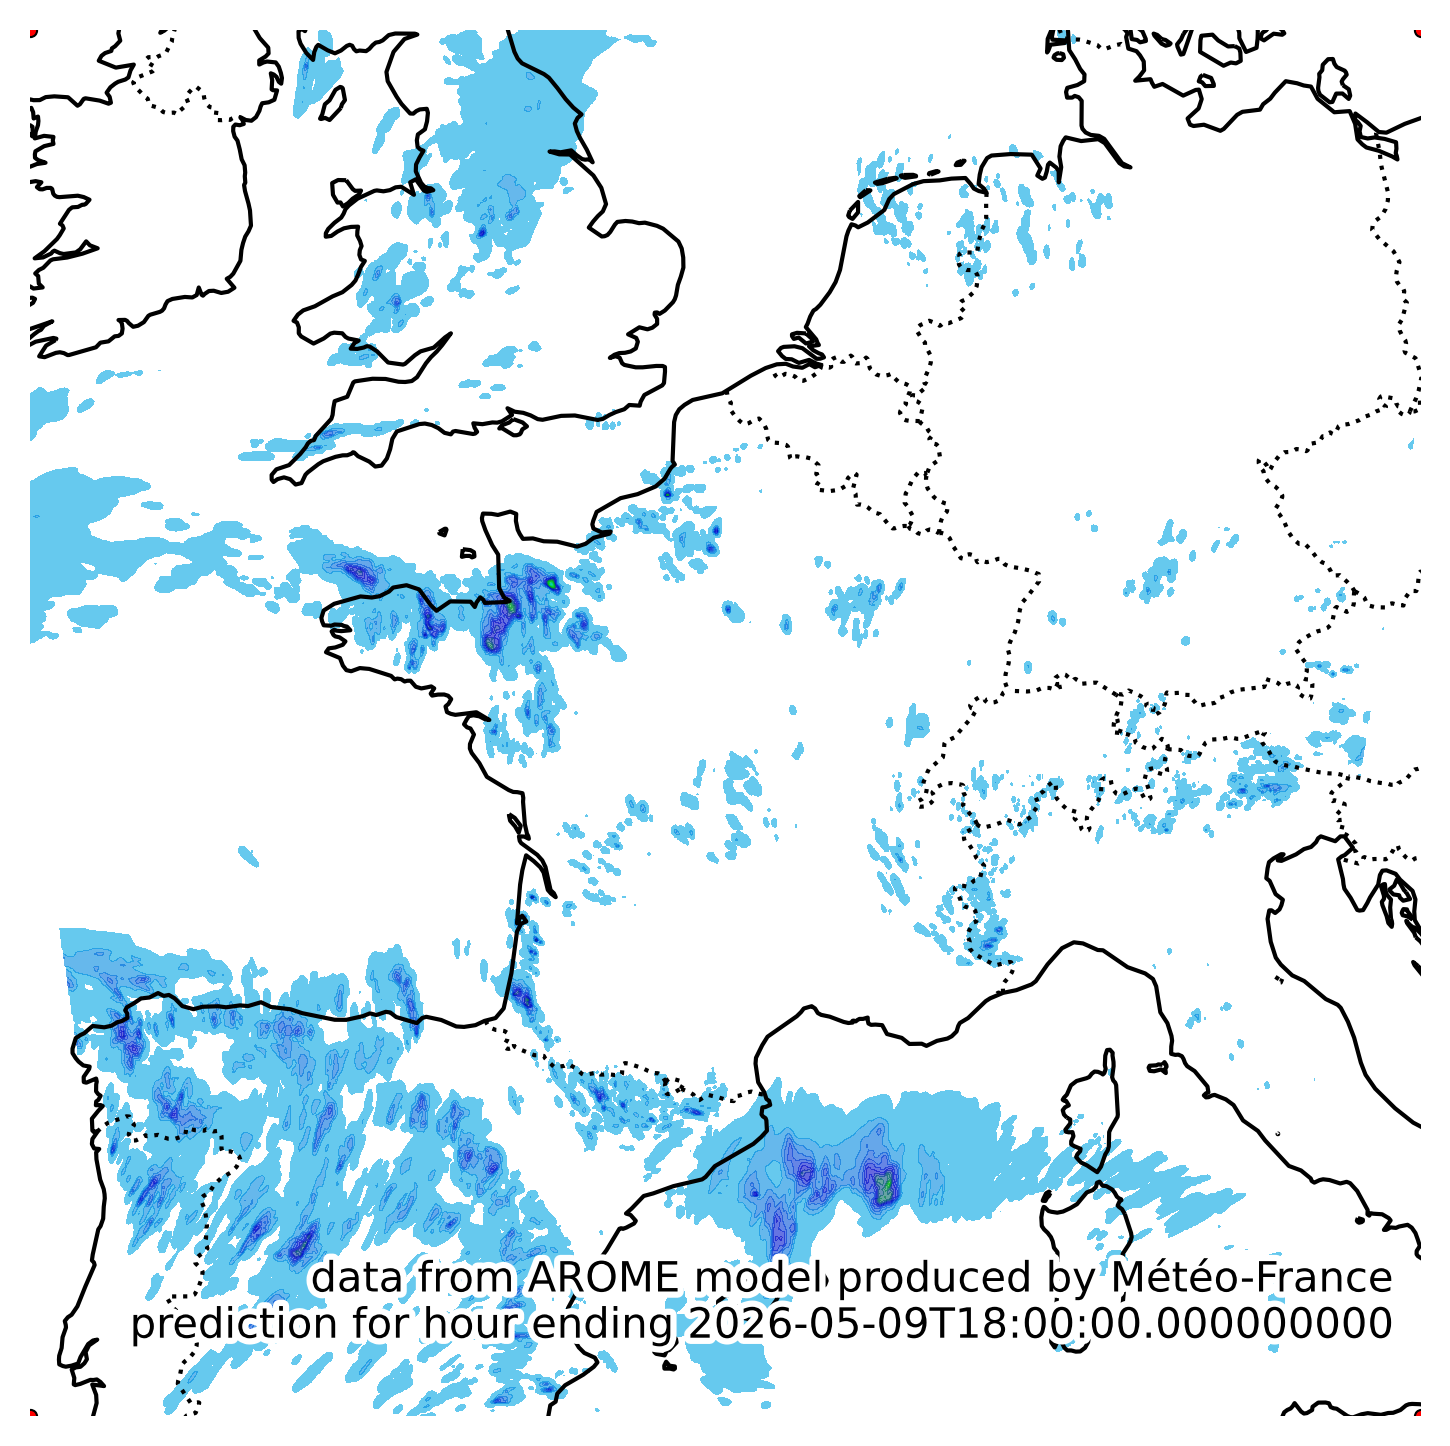

In [12]:
generate_maps.plot_rain_layer_to_png(
    layer=layer,
    output_dir=Path('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/temp/'),
    show=True,
    levels=20,
    vmin=0.01,
    )


In [20]:
import datetime as dt
from meteole import AromeForecast

# Configure the logger to provide information on data recovery: recovery status, default settings, etc.
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("meteole")

APP_ID = "b05qRlVpWU40V291OExpd2dxR2Jmc3VQTDlvYTpqb1NIbFpuREFOMDJIbVAzZGZPMDRmVHF4VElh"
# Initialize the AROME forecast client
# Find your APPLICATION_ID by following these guidelines: https://maif.github.io/meteole/how_to/?h=application_id#get-a-token-an-api-key-or-an-application-id
arome_client = AromeForecast(application_id=APP_ID)

# Check indicators available
print(arome_client.indicators)
arome_client.get_capabilities()['indicator'].unique()

INFO:meteole.forecast:Fetching all available coverages...
INFO:meteole.forecast:
	 Successfully fetched 5756 coverages,
	 representing 46 different indicators,
	 across the last 35 runs (from 2026-05-08T00.00.00Z to 2026-05-12T06.00.00Z)

	 Default run for `get_coverage`: 2026-05-12T06.00.00Z)


['GEOMETRIC_HEIGHT__GROUND_OR_WATER_SURFACE', 'BRIGHTNESS_TEMPERATURE__GROUND_OR_WATER_SURFACE', 'CONVECTIVE_AVAILABLE_POTENTIAL_ENERGY__GROUND_OR_WATER_SURFACE', 'CONVECTIVE_INHIBITION__GROUND_OR_WATER_SURFACE', 'PRECIPITABLE_WATER__GROUND_OR_WATER_SURFACE', 'TOTAL_WATER_PRECIPITATION__GROUND_OR_WATER_SURFACE', 'WIND_SPEED_GUST__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND', 'WIND_SPEED__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND', 'SHORT_WAVE_RADIATION_FLUX_CLEAR_SKY__GROUND_OR_WATER_SURFACE', 'SENSIBLE_HEAT_NET_FLUX__GROUND_OR_WATER_SURFACE', 'DOWNWARD_DIRECT_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE', 'DOWNWARD_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE', 'SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE', 'DOWNWARD_LONG_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE', 'LONG_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE', 'GRAUPEL__GROUND_OR_WATER_SURFACE', 'HAIL__GROUND_OR_WATER_SURFACE', 'SNOW_DEPTH__GROUND_OR_WATER_SURFACE', 'RELATIVE_HUMIDITY__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND',

<StringArray>
[                            'GEOMETRIC_HEIGHT__GROUND_OR_WATER_SURFACE',
                       'BRIGHTNESS_TEMPERATURE__GROUND_OR_WATER_SURFACE',
        'CONVECTIVE_AVAILABLE_POTENTIAL_ENERGY__GROUND_OR_WATER_SURFACE',
                        'CONVECTIVE_INHIBITION__GROUND_OR_WATER_SURFACE',
                           'PRECIPITABLE_WATER__GROUND_OR_WATER_SURFACE',
                    'TOTAL_WATER_PRECIPITATION__GROUND_OR_WATER_SURFACE',
                   'WIND_SPEED_GUST__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND',
                        'WIND_SPEED__SPECIFIC_HEIGHT_LEVEL_ABOVE_GROUND',
          'SHORT_WAVE_RADIATION_FLUX_CLEAR_SKY__GROUND_OR_WATER_SURFACE',
                       'SENSIBLE_HEAT_NET_FLUX__GROUND_OR_WATER_SURFACE',
    'DOWNWARD_DIRECT_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE',
           'DOWNWARD_SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE',
                    'SHORT_WAVE_RADIATION_FLUX__GROUND_OR_WATER_SURFACE',
            'DOWNWARD_LO

In [ ]:
import datetime
# Fetch weather data
df_arome = arome_client.get_coverage(
    indicator="TOTAL_WATER_PRECIPITATION__GROUND_OR_WATER_SURFACE",  # Optional: if not, you have to fill coverage_id
    # run="2025-01-10T00.00.00Z",                                                # Optional: forecast start time
    forecast_horizons=[datetime.timedelta(0), datetime.timedelta(seconds=3600),],
    # heights=[10],                                                              # Optional: height above ground level
    # pressures=None,                                                            # Optional: pressure level
    long = (-5.1413, 9.5602),                                                  # Optional: longitude. tuple (min_long, max_long) or a float for a specific location
    lat = (41.33356, 51.0889),                                                 # Optional: latitude. tuple (min_lat, max_lat) or a float for a specific location
    coverage_id=None,                                                          # Optional: an alternative to indicator/run/interval
    temp_dir=None,                                                             # Optional: Directory to store the temporary file
    )


INFO:meteole.forecast:Using latest `run=2026-05-12T06.00.00Z`.
INFO:meteole.forecast:`interval=None` is invalid  for non-instant indicators. Using default `interval=P1D`
INFO:meteole.forecast:Using `coverage_id=TOTAL_WATER_PRECIPITATION__GROUND_OR_WATER_SURFACE___2026-05-12T06.00.00Z_P1D`


INFO:meteole.forecast:Using `lat=(41.33, 51.09) (user input: (41.33356, 51.0889))`
INFO:meteole.forecast:Using `long=(-5.14, 9.56) (user input: (-5.1413, 9.5602))`


ValueError: `forecast_horizons=[datetime.timedelta(0), datetime.timedelta(seconds=3600)]` is invalid. Available forecast_horizons: [datetime.timedelta(days=1), datetime.timedelta(days=1, seconds=3600), datetime.timedelta(days=1, seconds=7200), datetime.timedelta(days=1, seconds=10800), datetime.timedelta(days=1, seconds=14400), datetime.timedelta(days=1, seconds=18000), datetime.timedelta(days=1, seconds=21600), datetime.timedelta(days=1, seconds=25200), datetime.timedelta(days=1, seconds=28800), datetime.timedelta(days=1, seconds=32400), datetime.timedelta(days=1, seconds=36000), datetime.timedelta(days=1, seconds=39600), datetime.timedelta(days=1, seconds=43200), datetime.timedelta(days=1, seconds=46800), datetime.timedelta(days=1, seconds=50400), datetime.timedelta(days=1, seconds=54000), datetime.timedelta(days=1, seconds=57600), datetime.timedelta(days=1, seconds=61200), datetime.timedelta(days=1, seconds=64800)]